In [1]:
import pandas as pd
import numpy as np
import warnings, re
from matplotlib import pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [34]:
df_bouts = pd.read_pickle('../data/cleaned_sumo_bouts.pkl')
df_tournaments = pd.read_pickle('../data/cleaned_sumo_tournaments.pkl')

df_tournaments['basho_dt'] = pd.to_datetime(df_tournaments['basho'].astype(str), format='%Y.%m')
df_bouts['basho_dt'] = pd.to_datetime(df_bouts['basho'].astype(str), format='%Y.%m')
df_bouts['year'] = df_bouts['basho_dt'].dt.year
df_tournaments['year'] = df_tournaments['basho_dt'].dt.year

In [35]:
df_bouts

,basho,day,bout_id,technique,win,name,heya,shusshin,birth_date,age,...,bouts_prev6,win_rate_prev6,opponent_cum_wins,opponent_cum_bouts,opponent_cum_win_rate,opponent_wins_prev6,opponent_bouts_prev6,opponent_win_rate_prev6,basho_dt,year
16,2015.05,2,45227,hatakikomi,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,15.0,0.466667,216,438,0.493151,40.0,77.0,0.519481,2015-05-01,2015
17,2015.05,3,45264,sukuinage,0,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,15.0,0.466667,83,165,0.503030,40.0,83.0,0.481928,2015-05-01,2015
18,2015.05,4,45295,tsukiotoshi,0,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,15.0,0.466667,3,6,0.500000,2.0,3.0,0.666667,2015-05-01,2015
19,2015.05,5,45329,uwatenage,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,15.0,0.466667,11,26,0.423077,8.0,22.0,0.363636,2015-05-01,2015
20,2015.05,6,45365,hatakikomi,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,15.0,0.466667,117,266,0.439850,33.0,76.0,0.434211,2015-05-01,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151519,2022.11,11,67538,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,90.0,0.422222,208,409,0.508557,39.0,76.0,0.513158,2022-11-01,2022
151520,2022.11,12,67572,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,90.0,0.422222,302,599,0.504174,42.0,88.0,0.477273,2022-11-01,2022
151521,2022.11,13,67605,yorikiri,1,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,90.0,0.422222,472,977,0.483112,43.0,90.0,0.477778,2022-11-01,2022
151522,2022.11,14,67640,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,90.0,0.422222,33,71,0.464789,27.0,58.0,0.465517,2022-11-01,2022


In [36]:
df_tournaments

,basho,name,heya,shusshin,age,division,height,weight,experience,rank_num,...,bouts_prev6_mean,win_rate_prev6_mean,opponent_cum_wins_mean,opponent_cum_bouts_mean,opponent_cum_win_rate_mean,opponent_wins_prev6_mean,opponent_bouts_prev6_mean,opponent_win_rate_prev6_mean,basho_dt,year
0,2000.03,Akebono,Azumazeki,U.S.A.,30.10,Maegashira,203.5,230.5,12.008219,1.0,...,15.0,0.733333,13.000000,22.000000,0.588693,8.866667,15.000000,0.591111,2000-03-01,2000
1,2000.03,Akinoshima,Futagoyama,Hiroshima,32.11,Maegashira,175.0,156.5,18.013699,14.0,...,15.0,0.466667,10.466667,21.266667,0.497952,7.266667,14.266667,0.508889,2000-03-01,2000
2,2000.03,Akinoshu,Izutsu,Hiroshima,31.10,Juryo,179.0,118.5,15.506849,29.0,...,15.0,0.666667,10.466667,22.000000,0.485061,7.466667,15.000000,0.497778,2000-03-01,2000
3,2000.03,Aminishiki,Ajigawa,Aomori,21.50,Juryo,184.0,113.5,3.164384,35.0,...,15.0,0.533333,10.200000,22.000000,0.470059,6.600000,15.000000,0.440000,2000-03-01,2000
4,2000.03,Asanosho,Wakamatsu,Kanagawa,30.20,Maegashira,185.5,144.5,8.005479,19.0,...,15.0,0.466667,11.000000,22.000000,0.505768,7.600000,15.000000,0.506667,2000-03-01,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10808,2025.07,Tomokaze,Nakamura,Kanagawa,30.70,Juryo,185.0,181.0,8.172603,29.0,...,87.0,0.517241,175.333333,361.666667,0.490829,36.866667,78.266667,0.474214,2025-07-01,2025
10809,2025.07,Tsurugisho,Oitekaze,Tokyo,33.11,Juryo,185.0,200.0,11.504110,36.0,...,89.0,0.449438,132.400000,275.933333,0.488351,28.200000,62.200000,0.453754,2025-07-01,2025
10810,2025.07,Ura,Kise,Osaka,33.00,Maegashira,175.0,139.0,10.342466,18.0,...,90.0,0.433333,255.000000,491.153846,0.559828,43.923077,84.307692,0.539834,2025-07-01,2025
10811,2025.07,Wakamotoharu,Arashio,Fukushima,31.90,Maegashira,187.0,147.0,13.673973,10.0,...,90.0,0.544444,202.000000,360.400000,0.585325,49.933333,87.133333,0.576991,2025-07-01,2025


In [37]:
df_tournaments.columns

Index(['basho', 'name', 'heya', 'shusshin', 'age', 'division', 'height',
       'weight', 'experience', 'rank_num', 'win_mean', 'win_sum', 'win_count',
       'opponent_rank_num_mean', 'age_diff_mean', 'height_diff_mean',
       'weight_diff_mean', 'experience_diff_mean', 'rank_diff_mean',
       'flag_higher_division_mean', 'flag_lower_division_mean',
       'flag_same_hometown_mean', 'cum_wins_mean', 'cum_bouts_mean',
       'cum_win_rate_mean', 'wins_prev6_mean', 'bouts_prev6_mean',
       'win_rate_prev6_mean', 'opponent_cum_wins_mean',
       'opponent_cum_bouts_mean', 'opponent_cum_win_rate_mean',
       'opponent_wins_prev6_mean', 'opponent_bouts_prev6_mean',
       'opponent_win_rate_prev6_mean', 'basho_dt', 'year'],
      dtype='object')

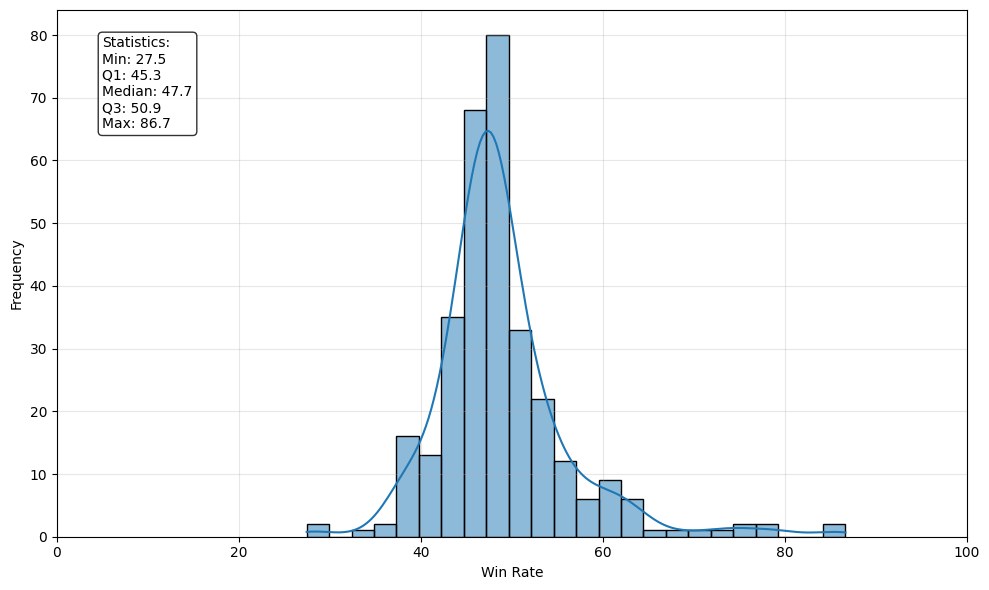

In [51]:
# Overall win rates by wrestler
df_overall = df_bouts.groupby('name').agg({'win': 'mean', 'bout_id': 'count', 'rank_num':'std'}).reset_index()
df_overall = df_overall[df_overall['bout_id'] >= 45] # at least 3 tournaments participated

df_overall['win'] = df_overall['win']*100

# Calculate statistics
stats = df_overall['win'].describe()

# Make a nice looking histogram with sns
plt.figure(figsize=(10,6))
sns.histplot(df_overall['win'], binwidth=2.5, kde=True)
plt.xlabel('Win Rate')
plt.ylabel('Frequency')
plt.xlim(0, 100)

# Add statistics text box
stats_text = f"""Statistics:
Min: {stats['min']:.1f}
Q1: {stats['25%']:.1f}
Median: {stats['50%']:.1f}
Q3: {stats['75%']:.1f}
Max: {stats['max']:.1f}"""

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top', fontsize=10)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../output/overall_win_rate_distribution.pdf')
plt.show()

In [54]:
df_overall.describe()

,win,bout_id,rank_num
count,315.000000,315.00000,315.000000
mean,48.924874,459.32381,5.877664
std,7.385530,343.81627,2.600612
min,27.450980,45.00000,0.000000
25%,45.315182,168.50000,3.895855
50%,47.714808,387.00000,6.166433
75%,50.916705,677.50000,7.808912
max,86.666667,1674.00000,12.339317


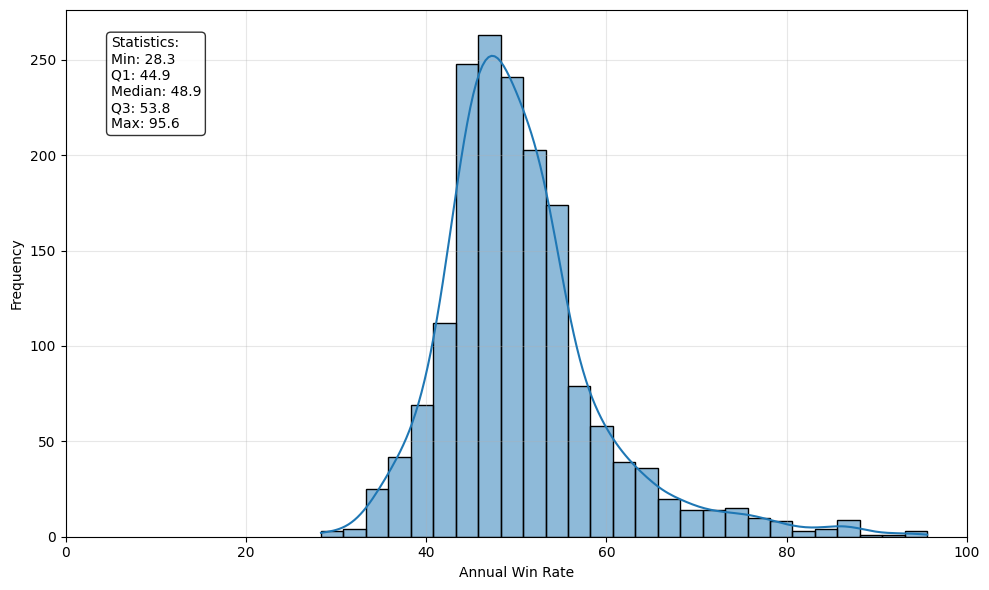

In [52]:
# Annual win rates by wrestler
df_annual = df_bouts.groupby(['name','year']).agg({'win': 'mean', 'bout_id': 'count', 'rank_num':'std'}).reset_index()
df_annual = df_annual[df_annual['bout_id'] >= 45] # at least 3 tournaments participated

df_annual['win'] = df_annual['win']*100

# Calculate statistics
stats = df_annual['win'].describe()

# Make a nice looking histogram with sns
plt.figure(figsize=(10,6))
sns.histplot(df_annual['win'], binwidth=2.5, kde=True)
plt.xlabel('Annual Win Rate')
plt.ylabel('Frequency')
plt.xlim(0, 100)

# Add statistics text box
stats_text = f"""Statistics:
Min: {stats['min']:.1f}
Q1: {stats['25%']:.1f}
Median: {stats['50%']:.1f}
Q3: {stats['75%']:.1f}
Max: {stats['max']:.1f}"""

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top', fontsize=10)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../output/annual_win_rate_distribution.pdf')
plt.show()

In [50]:
# Table of +- win rate counts
count_tot = df_annual.shape[0]
count_pm_05 = df_annual[np.abs(df_annual['win'] - 50) >= 5].shape[0]
count_pm_10 = df_annual[np.abs(df_annual['win'] - 50) >= 10].shape[0]
count_pm_15 = df_annual[np.abs(df_annual['win'] - 50) >= 15].shape[0]
count_pm_20 = df_annual[np.abs(df_annual['win'] - 50) >= 20].shape[0]
count_pm_25 = df_annual[np.abs(df_annual['win'] - 50) >= 25].shape[0]

print(f"Total wrestler-years: {count_tot}")
print(f"Wrestler-years with ±5% from 50%: {count_pm_05} ({count_pm_05/count_tot*100:.1f}%)")
print(f"Wrestler-years with ±10% from 50%: {count_pm_10} ({count_pm_10/count_tot*100:.1f}%)")
print(f"Wrestler-years with ±15% from 50%: {count_pm_15} ({count_pm_15/count_tot*100:.1f}%)")
print(f"Wrestler-years with ±20% from 50%: {count_pm_20} ({count_pm_20/count_tot*100:.1f}%)")
print(f"Wrestler-years with ±25% from 50%: {count_pm_25} ({count_pm_25/count_tot*100:.1f}%)")


Total wrestler-years: 1698
Wrestler-years with ±5% from 50%: 786 (46.3%)
Wrestler-years with ±10% from 50%: 324 (19.1%)
Wrestler-years with ±15% from 50%: 132 (7.8%)
Wrestler-years with ±20% from 50%: 73 (4.3%)
Wrestler-years with ±25% from 50%: 44 (2.6%)


In [45]:
df_annual

,name,year,win,bout_id,rank_num
0,Abi,2015,41.304348,46,1.515141
1,Abi,2016,0.000000,2,1.414214
2,Abi,2017,68.181818,44,3.776247
3,Abi,2018,50.000000,90,3.997893
4,Abi,2019,60.000000,90,4.243303
...,...,...,...,...,...
2324,Yutakayama,2018,46.590909,88,4.267918
2325,Yutakayama,2019,48.888889,90,4.599096
2326,Yutakayama,2020,47.058824,68,4.261920
2327,Yutakayama,2021,49.438202,89,3.176981


In [33]:
# Calculate std by tournament
df_sub = df_tournaments[['basho_dt','age','height','weight', 'win_mean']]
grouped = df_sub.groupby('basho_dt')
std_df = grouped.std().reset_index()
std_df

,basho_dt,age,height,weight,win_mean
0,2000-03-01,3.713981,5.415086,25.399881,0.182307
1,2000-05-01,3.602657,5.417228,22.929584,0.182090
2,2000-07-01,3.661764,5.558284,22.021132,0.166424
3,2000-09-01,3.819462,5.731987,23.588729,0.181320
4,2000-11-01,3.531051,5.474290,23.379344,0.161491
...,...,...,...,...,...
146,2024-11-01,4.237183,5.856343,20.055383,0.174870
147,2025-01-01,4.473795,5.797918,20.751100,0.174497
148,2025-03-01,4.653045,5.634207,19.697671,0.156728
149,2025-05-01,4.536847,5.567114,19.232662,0.164014


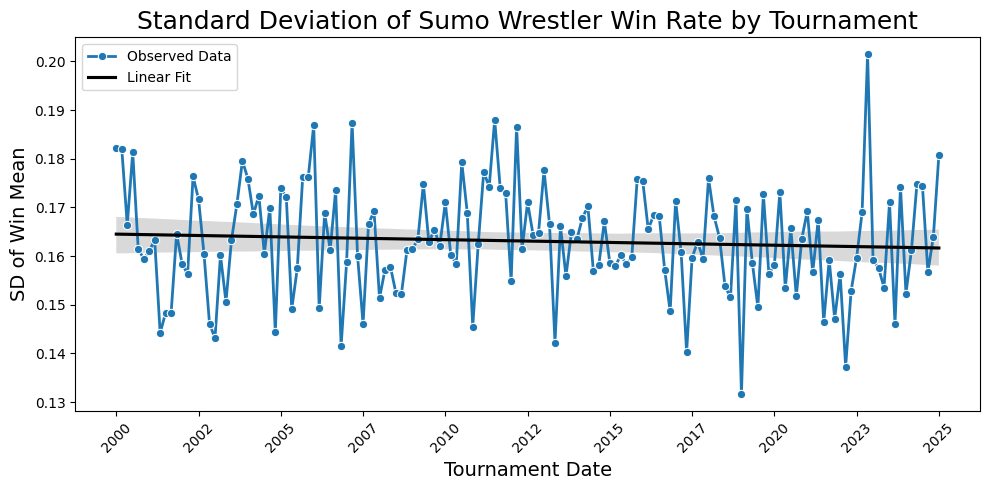

In [23]:
# Publication-ready line plot of win_mean vs basho_dt
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=std_df, x=std_df.index, y='win_mean', marker='o', linewidth=2, label='Observed Data')
# Add line of best fit
sns.regplot(data=std_df, x=std_df.index, y='win_mean', scatter=False, ax=ax, color='black', label='Linear Fit')
ax.set_title('Standard Deviation of Sumo Wrestler Win Rate by Tournament', fontsize=18)
ax.set_xlabel('Tournament Date', fontsize=14)
ax.set_ylabel('SD of Win Mean', fontsize=14)
# Set x-axis labels to show actual dates
ax.set_xticks(range(0, len(std_df), max(1, len(std_df)//10)))  # Show ~10 labels
ax.set_xticklabels([std_df.iloc[i]['basho_dt'].strftime('%Y') for i in range(0, len(std_df), max(1, len(std_df)//10))], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../output/std_win_mean_by_tournament.pdf')
plt.show()

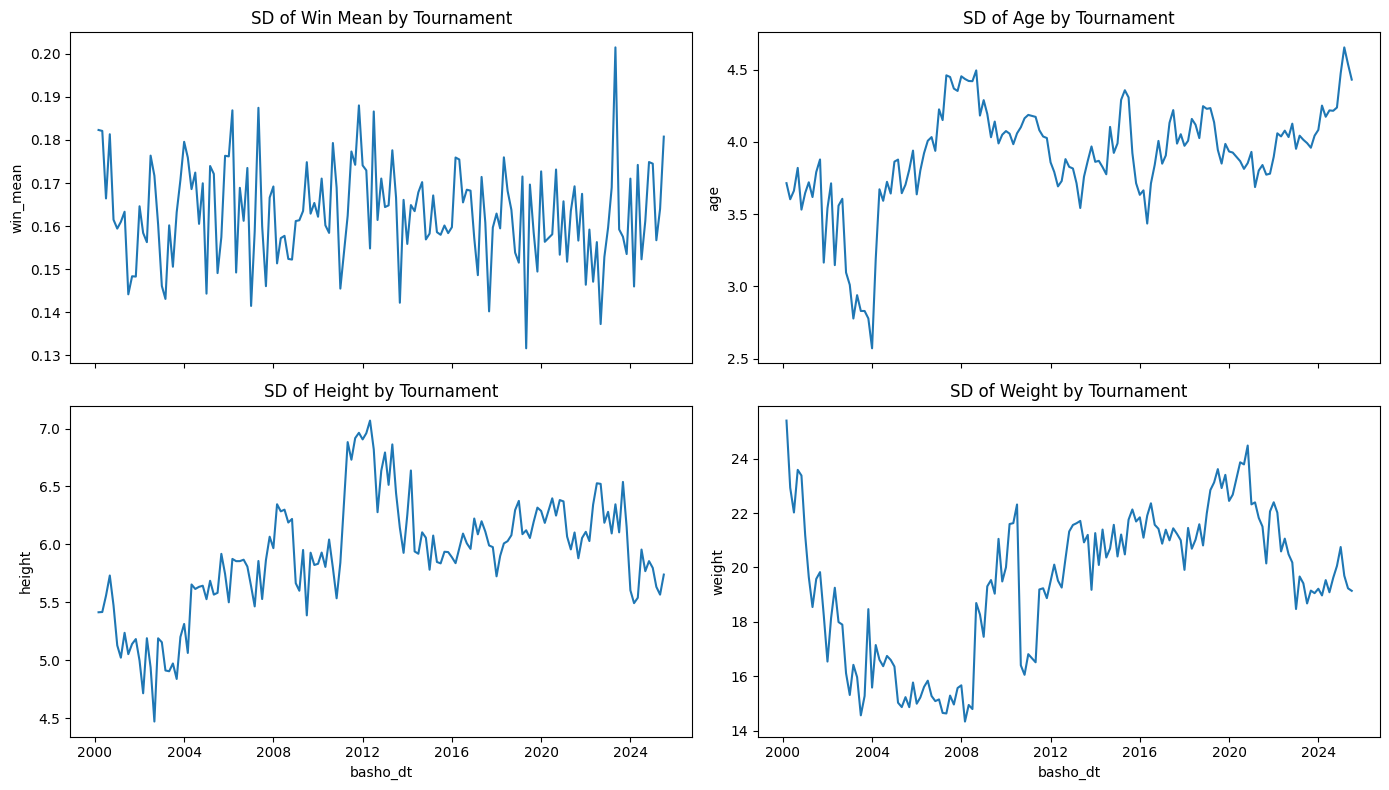

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

sns.lineplot(data=std_df, x='basho_dt', y='win_mean', ax=axes[0,0])
axes[0,0].set_title('SD of Win Mean by Tournament')

sns.lineplot(data=std_df, x='basho_dt', y='age', ax=axes[0,1])
axes[0,1].set_title('SD of Age by Tournament')

sns.lineplot(data=std_df, x='basho_dt', y='height', ax=axes[1,0])
axes[1,0].set_title('SD of Height by Tournament')

sns.lineplot(data=std_df, x='basho_dt', y='weight', ax=axes[1,1])
axes[1,1].set_title('SD of Weight by Tournament')

plt.tight_layout()
plt.show()

In [33]:
df_tournaments.describe()

,basho,age,height,weight,experience,rank_num,win_mean,win_sum,win_count,opponent_rank_num_mean,...,bouts_prev6_mean,win_rate_prev6_mean,opponent_cum_wins_mean,opponent_cum_bouts_mean,opponent_cum_win_rate_mean,opponent_wins_prev6_mean,opponent_bouts_prev6_mean,opponent_win_rate_prev6_mean,basho_dt,year
count,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,...,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855.000000,9855,9855.000000
mean,2012.569438,28.457889,183.806616,152.041786,9.343532,22.497108,0.498500,7.331811,14.637443,22.507010,...,78.046372,0.514406,187.488598,360.790140,0.521202,39.783171,78.004147,0.514077,2012-12-03 23:20:15.342465792,2012.509386
min,2000.030000,17.100000,165.000000,91.000000,0.328767,1.000000,0.000000,0.000000,7.000000,3.142857,...,1.000000,0.000000,8.272727,18.500000,0.371585,5.000000,12.454545,0.333333,2000-03-01 00:00:00,2000.000000
25%,2006.090000,25.600000,180.000000,140.000000,5.838356,13.000000,0.400000,6.000000,15.000000,11.933333,...,77.000000,0.455556,123.266667,251.866667,0.498650,33.933333,71.466667,0.485731,2006-09-01 00:00:00,2006.000000
50%,2013.010000,28.200000,184.000000,151.000000,9.008219,22.000000,0.500000,7.000000,15.000000,20.866667,...,90.000000,0.500000,180.666667,355.533333,0.515839,41.866667,83.666667,0.505282,2013-01-01 00:00:00,2013.000000
75%,2019.030000,31.100000,188.000000,163.700000,12.506849,33.000000,0.600000,9.000000,15.000000,33.133333,...,90.000000,0.547247,252.933333,480.900000,0.541921,46.000000,87.200000,0.543045,2019-03-01 00:00:00,2019.000000
max,2025.070000,40.900000,204.000000,264.500000,23.347945,41.000000,1.000000,15.000000,19.000000,39.714286,...,95.000000,1.000000,467.266667,824.600000,0.694056,59.428571,90.500000,0.694501,2025-07-01 00:00:00,2025.000000
std,7.306864,3.919265,5.914145,19.936275,4.554337,11.218559,0.162293,2.497187,1.088045,10.516315,...,21.981245,0.098848,85.361298,151.181891,0.034141,8.528600,12.873668,0.042457,NaN,7.308261


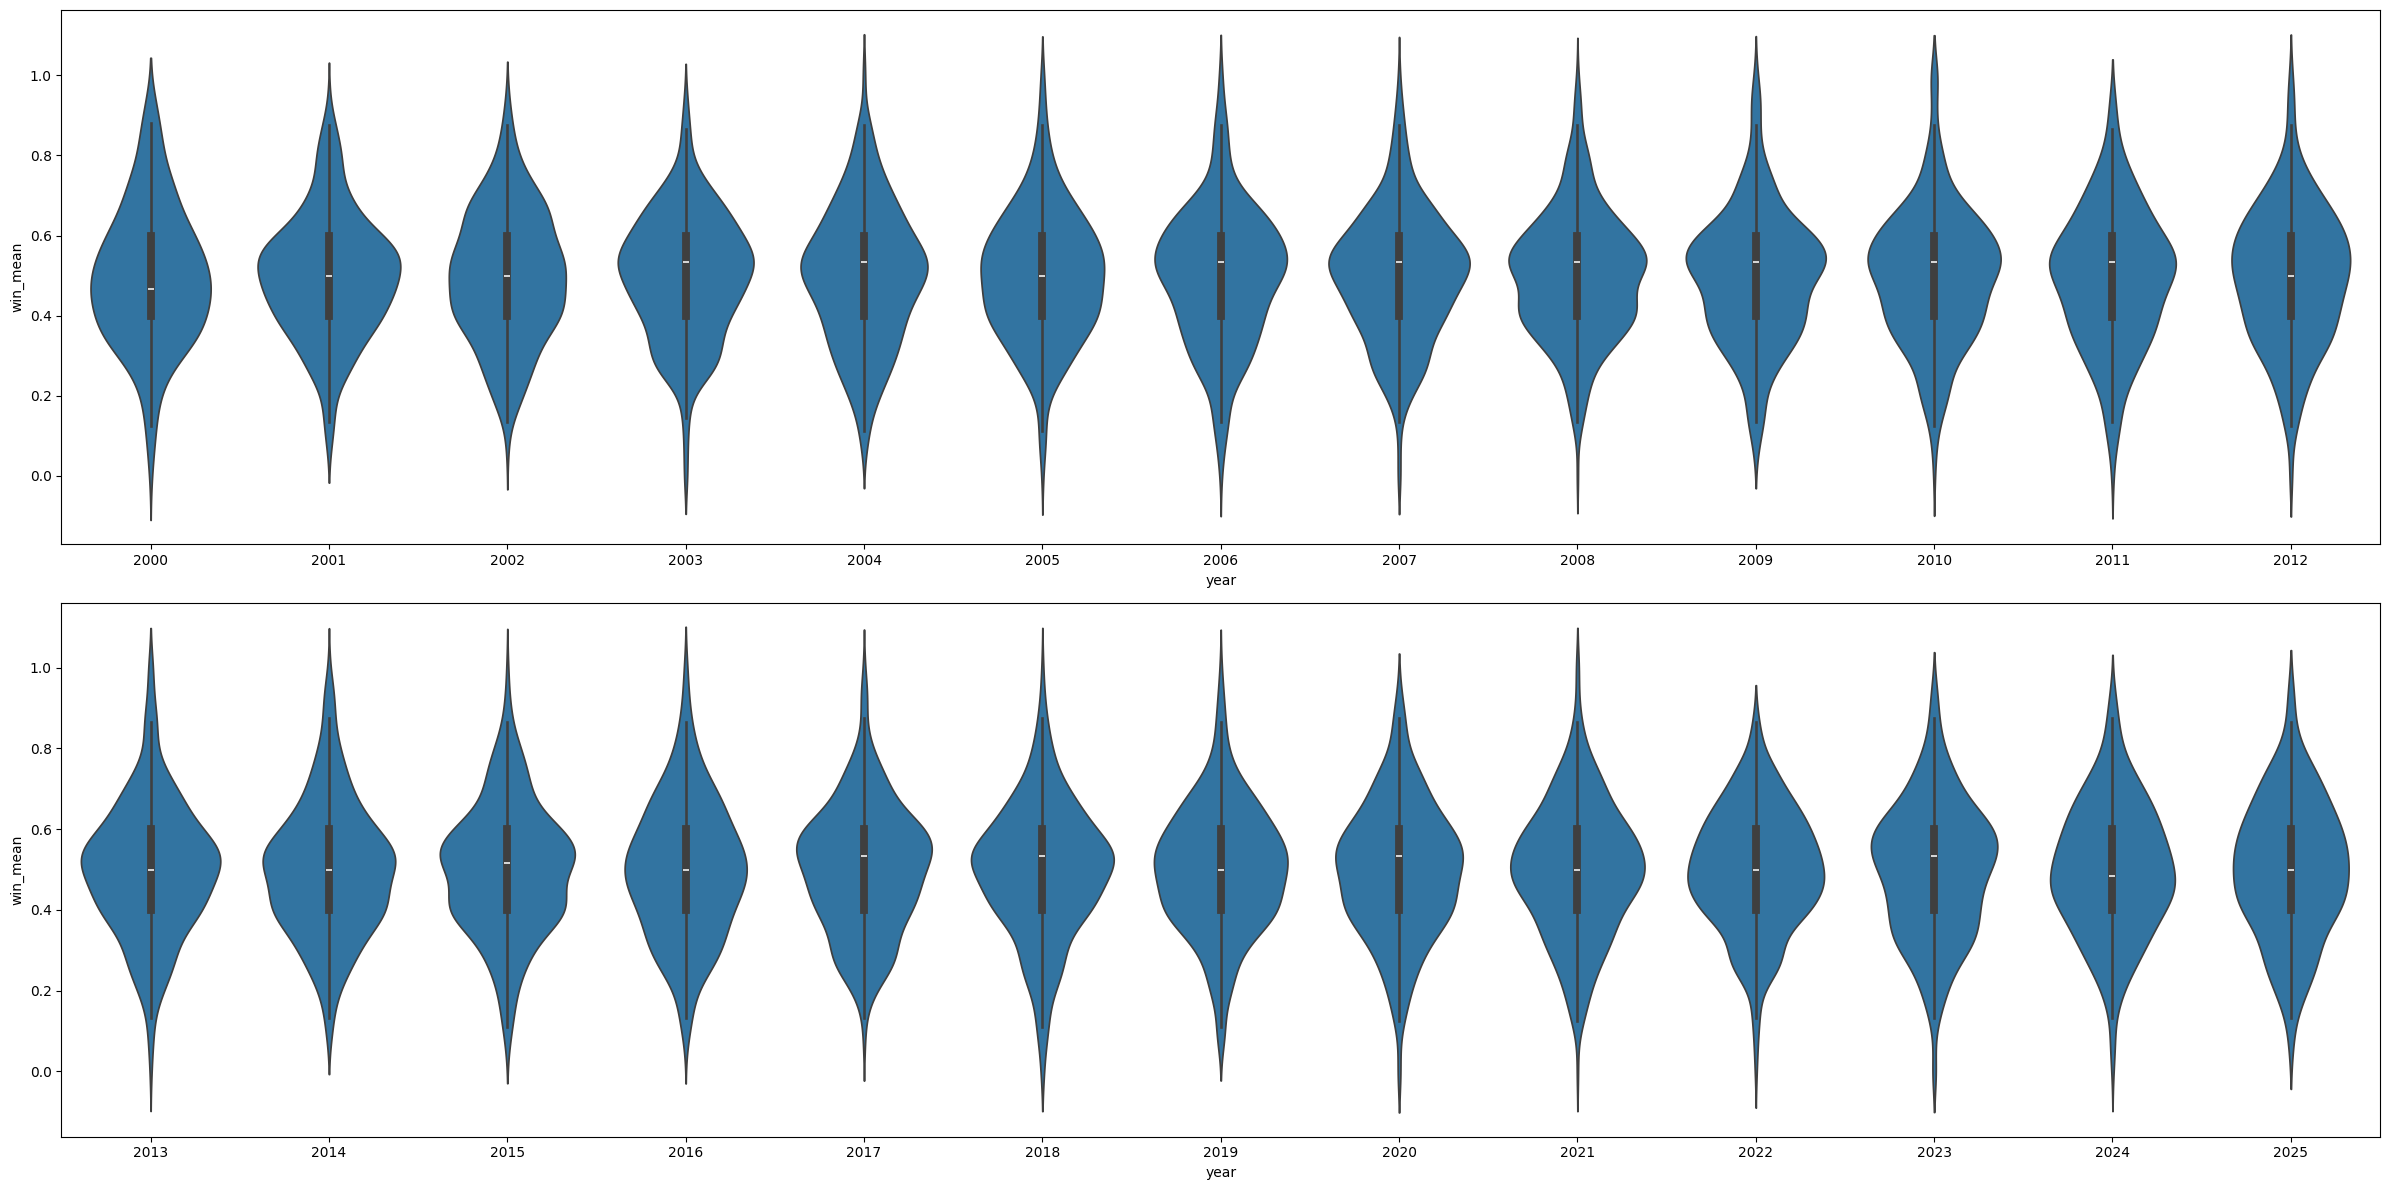

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(24, 12))

sns.violinplot(data=df_tournaments[df_tournaments['year']<2013], x='year', y='win_mean', fill=True, gridsize=500, ax=axes[0])
sns.violinplot(data=df_tournaments[df_tournaments['year']>=2013], x='year', y='win_mean', fill=True, gridsize=500, ax=axes[1])

plt.tight_layout()
plt.show()